In [1]:
import pandas as pd
import polars as pl

# Precision/Recall/F1

Generate precision/recall/f1 scores for the test run of wags-llm. This could be used to improve tooling or perform prompt engineering.

### Load Data


Load in the excel files

In [2]:
results_df = pd.read_csv('2026-06-29-interaction_classifications-rohit.csv',sep=',')
context_df = pd.read_excel('../../../data/2026-06-29-test2-RohitList-wText.xlsx')

truth_df = context_df.copy()
pred_df = results_df.copy()

In [3]:
pred_df.head()

,run_idx,prompt_version,temperature,used_raw_drug_candidates,seed_gene,used_pmid_to_genes,gene_source,pmid,block_id,skipped,...,raw_gene_count,result_error_message,drug,gene,interaction,interaction_type,directionality,evidence,classification_error_message,error_message
0,0,v2,0,False,NaN,True,pmid_to_genes,22608338,0,False,...,3,NaN,dabrafenib,BRAF,True,inhibition,inhibitory,NaN,NaN,NaN
1,0,v2,0,False,NaN,True,pmid_to_genes,22735384,1,False,...,3,NaN,dabrafenib,BRAF,True,inhibitor,inhibitory,NaN,NaN,NaN
2,0,v2,0,False,NaN,True,pmid_to_genes,22735384,1,False,...,3,NaN,dacarbazine,BRAF,False,NaN,NaN,NaN,The abstract describes dacarbazine as a compar...,The abstract describes dacarbazine as a compar...
3,0,v2,0,False,NaN,True,pmid_to_genes,38756640,2,False,...,8,NaN,avapritinib,BRAF,False,NaN,NaN,Avapritinib is mentioned only in the context o...,NaN,NaN
4,0,v2,0,False,NaN,True,pmid_to_genes,38756640,2,False,...,8,NaN,dabrafenib,BRAF,True,inhibition,inhibitory,NaN,NaN,NaN


In [4]:
truth_df.head()

,Unnamed: 0,pmid,drug_name,gene_name,context
0,0,22608338,DABRAFENIB,BRAF,BACKGROUND: Dabrafenib is an inhibitor of BRAF...
1,1,22735384,DABRAFENIB,BRAF,"BACKGROUND: Dabrafenib, an inhibitor of mutate..."
2,2,38756640,DABRAFENIB,BRAF,BACKGROUND: Gastrointestinal stromal tumor (GI...
3,3,24508103,VEMURAFENIB,BRAF,"BACKGROUND: In the BRIM-3 trial, vemurafenib w..."
4,4,27460442,VEMURAFENIB,BRAF,BACKGROUND: About half of patients with papill...


In [5]:
pred_df['gene'].value_counts(dropna=False)

gene
EGFR      16
ACE       13
ROS1      13
FLT3      13
BRAF      12
KRAS      11
ALK       11
RET       10
KIT        9
IDH2       7
TOP1       7
FGFR2      7
FGFR3      6
NaN        6
JAK2       5
HMGCR      5
NRAS       5
PDGFRA     5
CDKN2A     5
ATM        4
GNA11      4
IDH1       4
VDR        4
ERBB2      4
JAK3       3
CSF3R      3
MAP2K1     3
PIK3CA     3
KDR        3
SMO        2
TSC1       1
FGFR1      1
TSC2       1
Name: count, dtype: int64

In [6]:
print(f"Total drug candidates found: {pred_df['gene'].notnull().sum()}")

Total drug candidates found: 200


In [7]:
print(f"Number of PMIDs present in DGIdb for {truth_df['gene_name'][0]}: {len(truth_df['pmid'].unique())}")

Number of PMIDs present in DGIdb for BRAF: 100


Analysis

In [8]:
truth = truth_df.copy()
pred = pred_df.copy()

truth["drug"] = truth["drug_name"].str.upper().str.strip()
truth["gene"] = truth["gene_name"].str.upper().str.strip()

pred["drug"] = pred["drug"].str.upper().str.strip()
pred["gene"] = pred["gene"].str.upper().str.strip()

In [9]:
truth_pairs = (
    truth[
        ["pmid", "drug", "gene"]
    ]
    .drop_duplicates()
)

truth_pairs["truth"] = True

In [10]:
pred_pairs = (
    pred[
        ["pmid", "drug", "gene", "interaction"]
    ]
    .drop_duplicates()
)

pred_pairs = pred_pairs.rename(
    columns={"interaction": "predicted"}
)

In [11]:
pred_pairs = pred_pairs.dropna(subset=["pmid", "drug", "gene"])
truth_pairs = truth_pairs.dropna(subset=["pmid", "drug", "gene"])

In [12]:
eval_df = pred_pairs.merge(
    truth_pairs,
    on=["pmid", "drug", "gene"],
    how="left"
)

eval_df["truth"] = eval_df["truth"].fillna(False)

/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_74171/1255973576.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df["truth"] = eval_df["truth"].fillna(False)


In [13]:
pred_df

,run_idx,prompt_version,temperature,used_raw_drug_candidates,seed_gene,used_pmid_to_genes,gene_source,pmid,block_id,skipped,...,raw_gene_count,result_error_message,drug,gene,interaction,interaction_type,directionality,evidence,classification_error_message,error_message
0,0,v2,0,False,NaN,True,pmid_to_genes,22608338,0,False,...,3,NaN,dabrafenib,BRAF,True,inhibition,inhibitory,NaN,NaN,NaN
1,0,v2,0,False,NaN,True,pmid_to_genes,22735384,1,False,...,3,NaN,dabrafenib,BRAF,True,inhibitor,inhibitory,NaN,NaN,NaN
2,0,v2,0,False,NaN,True,pmid_to_genes,22735384,1,False,...,3,NaN,dacarbazine,BRAF,False,NaN,NaN,NaN,The abstract describes dacarbazine as a compar...,The abstract describes dacarbazine as a compar...
3,0,v2,0,False,NaN,True,pmid_to_genes,38756640,2,False,...,8,NaN,avapritinib,BRAF,False,NaN,NaN,Avapritinib is mentioned only in the context o...,NaN,NaN
4,0,v2,0,False,NaN,True,pmid_to_genes,38756640,2,False,...,8,NaN,dabrafenib,BRAF,True,inhibition,inhibitory,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0,v2,0,False,NaN,True,pmid_to_genes,33685866,99,False,...,8,NaN,cabozantinib s-malate,ROS1,True,inhibitor,inhibitory,NaN,NaN,NaN
202,0,v2,0,False,NaN,True,pmid_to_genes,33685866,99,False,...,8,NaN,crizotinib,ROS1,True,inhibitor,inhibitory,NaN,NaN,NaN
203,0,v2,0,False,NaN,True,pmid_to_genes,33685866,99,False,...,8,NaN,entrectinib,ROS1,True,inhibitor,inhibitory,NaN,NaN,NaN
204,0,v2,0,False,NaN,True,pmid_to_genes,33685866,99,False,...,8,NaN,lorlatinib,ROS1,True,inhibition,inhibitory,NaN,NaN,NaN


In [14]:
eval_df

,pmid,drug,gene,predicted,truth
0,22608338,DABRAFENIB,BRAF,True,True
1,22735384,DABRAFENIB,BRAF,True,True
2,22735384,DACARBAZINE,BRAF,False,False
3,38756640,AVAPRITINIB,BRAF,False,False
4,38756640,DABRAFENIB,BRAF,True,True
...,...,...,...,...,...
195,33685866,CABOZANTINIB S-MALATE,ROS1,True,False
196,33685866,CRIZOTINIB,ROS1,True,False
197,33685866,ENTRECTINIB,ROS1,True,False
198,33685866,LORLATINIB,ROS1,True,True


In [15]:
eval_df["predicted"].value_counts(dropna=False)

predicted
True     132
False     68
Name: count, dtype: int64

In [16]:
tp = ((eval_df["truth"] == True) & (eval_df["predicted"] == True)).sum()
fp = ((eval_df["truth"] == False) & (eval_df["predicted"] == True)).sum()
tn = ((eval_df["truth"] == False) & (eval_df["predicted"] == False)).sum()
fn = ((eval_df["truth"] == True) & (eval_df["predicted"] == False)).sum()

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
accuracy = (tp + tn) / (tp + fp + tn + fn) if tp + fp + tn + fn else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

pd.Series({
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn,
    "precision": precision,
    "recall": recall,
    "accuracy": accuracy,
    "f1": f1,
})

tp           84.000000
fp           48.000000
tn           68.000000
fn            0.000000
precision     0.636364
recall        1.000000
accuracy      0.760000
f1            0.777778
dtype: float64

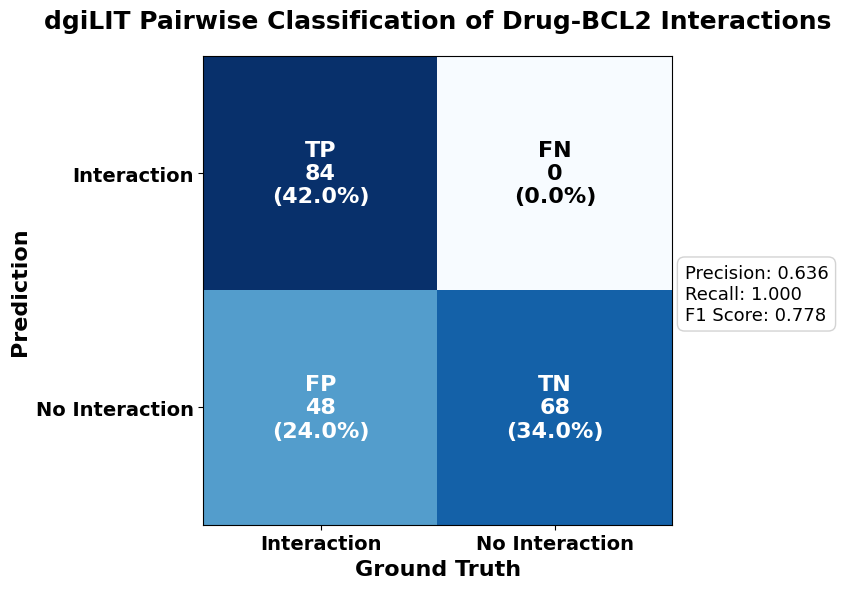

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Confusion matrix values
# ------------------------------------------------------------------

tp = ((eval_df["truth"] == True) & (eval_df["predicted"] == True)).sum()
fp = ((eval_df["truth"] == False) & (eval_df["predicted"] == True)).sum()
tn = ((eval_df["truth"] == False) & (eval_df["predicted"] == False)).sum()
fn = ((eval_df["truth"] == True) & (eval_df["predicted"] == False)).sum()

cm = np.array([
    [tp, fn],
    [fp, tn]
])

total = cm.sum()

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Ground Truth",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Prediction",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "dgiLIT Pairwise Classification of Drug-BCL2 Interactions",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

# ------------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------------

for i in range(2):
    for j in range(2):

        count = cm[i, j]
        pct = (count / total) * 100

        label = (
            "TP" if (i == 0 and j == 0)
            else "FN" if (i == 0 and j == 1)
            else "FP" if (i == 1 and j == 0)
            else "TN"
        )

        ax.text(
            j,
            i,
            f"{label}\n{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if count > cm.max() * 0.55 else "black",
        )

# ------------------------------------------------------------------
# Metrics box
# ------------------------------------------------------------------

metrics_text = (
    f"Precision: {precision:.3f}\n"
    f"Recall: {recall:.3f}\n"
    f"F1 Score: {f1:.3f}"
)

plt.figtext(
    0.88,
    0.50,
    metrics_text,
    fontsize=13,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    ),
)

# Clean up appearance
ax.set_aspect("equal")

plt.tight_layout()

# Uncomment for manuscript-quality export
# plt.savefig(
#     "bcl2_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [18]:
truth_set = set(
    truth_df.assign(
        drug=lambda x: x["drug_name"].str.upper().str.strip()
    )[["pmid", "drug"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

predicted_set = set(
    pred_df[
        pred_df["interaction"] == True
    ].assign(
        drug=lambda x: x["drug"].str.upper().str.strip()
    )[["pmid", "drug"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

recovered = truth_set & predicted_set

recovery_rate = len(recovered) / len(truth_set)

print(f"Recovered {len(recovered)} of {len(truth_set)} interactions")
print(f"Recovery Rate = {recovery_rate:.1%}")

Recovered 84 of 100 interactions
Recovery Rate = 84.0%


### PRint Outs

In [19]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def norm_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).upper().strip()

def candidate_contains_drug(candidate_string, drug):
    if pd.isna(candidate_string) or pd.isna(drug):
        return False

    candidates = {
        norm_text(x)
        for x in str(candidate_string).split(";")
        if str(x).strip()
    }

    return norm_text(drug) in candidates


# ------------------------------------------------------------------
# Normalize truth and prediction data
# ------------------------------------------------------------------

truth_norm = truth_df.copy()
truth_norm["drug"] = truth_norm["drug_name"].map(norm_text)
truth_norm["gene"] = truth_norm["gene_name"].map(norm_text)
truth_norm = truth_norm[truth_norm["gene"] == "BCL2"].copy()

pred_norm = pred_df.copy()
pred_norm["drug"] = pred_norm["drug"].map(norm_text)
pred_norm["gene"] = pred_norm["gene"].map(norm_text)
pred_norm = pred_norm[pred_norm["gene"] == "BCL2"].copy()

# Drop skipped / empty prediction rows
pred_norm = pred_norm.dropna(subset=["pmid", "drug", "gene"])

truth_pairs = (
    truth_norm[["pmid", "drug", "gene"]]
    .drop_duplicates()
    .assign(truth=True)
)

pred_pairs = (
    pred_norm[["pmid", "drug", "gene", "interaction"]]
    .drop_duplicates()
    .rename(columns={"interaction": "predicted"})
)

# ------------------------------------------------------------------
# Build evaluation table
# ------------------------------------------------------------------

eval_full = truth_pairs.merge(
    pred_pairs,
    on=["pmid", "drug", "gene"],
    how="outer"
)

eval_full["truth"] = eval_full["truth"].fillna(False)
eval_full["predicted"] = eval_full["predicted"].fillna(False)

eval_full["classification"] = np.select(
    [
        (eval_full["truth"] == True) & (eval_full["predicted"] == True),
        (eval_full["truth"] == False) & (eval_full["predicted"] == True),
        (eval_full["truth"] == False) & (eval_full["predicted"] == False),
        (eval_full["truth"] == True) & (eval_full["predicted"] == False),
    ],
    ["TP", "FP", "TN", "FN"],
    default="UNKNOWN"
)

# ------------------------------------------------------------------
# Add prediction details
# ------------------------------------------------------------------

pred_details = pred_norm[
    [
        "pmid",
        "block_id",
        "drug",
        "gene",
        "candidate_drugs",
        "candidate_genes",
        "interaction",
        "interaction_type",
        "directionality",
        "evidence",
        "error_message",
    ]
].drop_duplicates(subset=["pmid", "drug", "gene"])

review_df = eval_full.merge(
    pred_details,
    on=["pmid", "drug", "gene"],
    how="left"
)

# Add truth context / metadata
truth_detail_cols = [
    "pmid",
    "drug",
    "gene",
    "drug_name",
    "gene_name",
    "drug_concept_id",
    "sources",
    "context",
]

truth_detail_cols = [
    col for col in truth_detail_cols
    if col in truth_norm.columns
]

truth_details = (
    truth_norm[truth_detail_cols]
    .drop_duplicates(subset=["pmid", "drug", "gene"])
)

review_df = review_df.merge(
    truth_details,
    on=["pmid", "drug", "gene"],
    how="left"
)

# If context is missing for FP rows, try to recover PMID-level context from truth_df
pmid_context = (
    truth_norm[["pmid", "context"]]
    .drop_duplicates(subset=["pmid"])
    .rename(columns={"context": "pmid_context"})
)

review_df = review_df.merge(
    pmid_context,
    on="pmid",
    how="left"
)

review_df["review_context"] = review_df["context"].fillna(review_df["pmid_context"])

# Manual review fields
review_df["manual_review"] = ""
review_df["manual_notes"] = ""

# ------------------------------------------------------------------
# FP / FN workbook
# ------------------------------------------------------------------

fp_df = review_df[review_df["classification"] == "FP"].copy()
fn_df = review_df[review_df["classification"] == "FN"].copy()

fp_columns = [
    "classification",
    "pmid",
    "drug",
    "gene",
    "predicted",
    "truth",
    "interaction_type",
    "directionality",
    "evidence",
    "candidate_drugs",
    "candidate_genes",
    "review_context",
    "manual_review",
    "manual_notes",
]

fn_columns = [
    "classification",
    "pmid",
    "drug",
    "gene",
    "predicted",
    "truth",
    "candidate_drugs",
    "candidate_genes",
    "drug_name",
    "drug_concept_id",
    "sources",
    "review_context",
    "manual_review",
    "manual_notes",
]

with pd.ExcelWriter("2026-06-15-bcl2_fp_fn_manual_review.xlsx", engine="xlsxwriter") as writer:
    fp_df[fp_columns].to_excel(writer, sheet_name="False Positives", index=False)
    fn_df[fn_columns].to_excel(writer, sheet_name="False Negatives", index=False)
    review_df.to_excel(writer, sheet_name="All Evaluated Pairs", index=False)

    workbook = writer.book

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, 0, 20)
        worksheet.set_column(0, 5, 14)
        worksheet.set_column(6, 10, 24)
        worksheet.set_column(11, 11, 80)
        worksheet.set_column(12, 13, 24)


# ------------------------------------------------------------------
# Interaction recovery workbook
# ------------------------------------------------------------------

# One row per original truth interaction
recovery_df = truth_norm[
    [
        "pmid",
        "drug",
        "gene",
        "drug_name",
        "gene_name",
        "drug_concept_id",
        "sources",
        "context",
    ]
].drop_duplicates(subset=["pmid", "drug", "gene"]).copy()

# Add candidate drug list per PMID
candidate_by_pmid = (
    pred_norm[["pmid", "candidate_drugs"]]
    .dropna()
    .drop_duplicates(subset=["pmid"])
)

recovery_df = recovery_df.merge(
    candidate_by_pmid,
    on="pmid",
    how="left"
)

recovery_df["candidate_present"] = recovery_df.apply(
    lambda row: candidate_contains_drug(row["candidate_drugs"], row["drug"]),
    axis=1
)

# Add predicted status for exact PMID-drug-BCL2 pair
recovery_df = recovery_df.merge(
    pred_pairs,
    on=["pmid", "drug", "gene"],
    how="left"
)

recovery_df["predicted"] = recovery_df["predicted"].fillna(False)

recovery_df["recovered"] = (
    (recovery_df["candidate_present"] == True)
    & (recovery_df["predicted"] == True)
)

recovery_df["failure_mode"] = np.select(
    [
        recovery_df["recovered"] == True,
        recovery_df["candidate_present"] == False,
        (recovery_df["candidate_present"] == True) & (recovery_df["predicted"] == False),
    ],
    [
        "Recovered",
        "Candidate drug not generated",
        "Candidate generated but classifier returned false",
    ],
    default="Unclear"
)

recovery_df["manual_review"] = ""
recovery_df["manual_notes"] = ""

missed_recovery_df = recovery_df[recovery_df["recovered"] == False].copy()

summary_df = pd.DataFrame(
    {
        "metric": [
            "Total truth interactions",
            "Candidate present",
            "Recovered",
            "Missed",
            "Candidate recall",
            "Interaction recovery rate",
            "Classifier recall given candidate present",
        ],
        "value": [
            len(recovery_df),
            int(recovery_df["candidate_present"].sum()),
            int(recovery_df["recovered"].sum()),
            int((~recovery_df["recovered"]).sum()),
            recovery_df["candidate_present"].mean(),
            recovery_df["recovered"].mean(),
            (
                recovery_df["recovered"].sum()
                / recovery_df["candidate_present"].sum()
                if recovery_df["candidate_present"].sum() > 0
                else np.nan
            ),
        ],
    }
)

with pd.ExcelWriter("2026-06-29-rohit_interaction_recovery_review.xlsx", engine="xlsxwriter") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    recovery_df.to_excel(writer, sheet_name="All Truth Interactions", index=False)
    missed_recovery_df.to_excel(writer, sheet_name="Missed Interactions", index=False)

    workbook = writer.book

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, 0, 20)
        worksheet.set_column(0, 8, 18)
        worksheet.set_column(9, 9, 50)
        worksheet.set_column(10, 10, 80)
        worksheet.set_column(11, 15, 24)


print("Saved:")
print("2026-06-29-rohit_fp_fn_manual_review.xlsx")
print("2026-06-29-rohit_interaction_recovery_review.xlsx")
print()
print(summary_df)

KeyError: "['drug_concept_id', 'sources'] not in index"

### Human Review Scores

In [ ]:
review_df = pd.read_excel('2026-06-16-bcl2_fp_fn_manual_review-mc.xlsx',sheet_name='False Positives')
review_df["drug"] = review_df["drug"].str.upper().str.strip()
review_df["gene"] = review_df["gene"].str.upper().str.strip()

human_lookup = review_df[
    ["pmid", "drug", "gene", "human_truth"]
].copy()

eval_human = eval_df.merge(
    human_lookup,
    on=["pmid", "drug", "gene"],
    how="left"
)

eval_human["truth_star"] = eval_human["truth"]

mask = (
    (eval_human["truth"] == False)
    & (eval_human["human_truth"].notna())
)

eval_human.loc[mask, "truth_star"] = (
    eval_human.loc[mask, "human_truth"]
)

tp_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == True)
).sum()

fp_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == True)
).sum()

tn_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == False)
).sum()

fn_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == False)
).sum()


/var/folders/5t/sfw5tjx56m10xb861_pd3wfm0000gq/T/ipykernel_30339/2616761274.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True True True True True True False True True True True True
 True True True False True True True True True True True True True True
 True False True True True True True True True True True True True False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  eval_human.loc[mask, "truth_star"] = (


TP*: 61
FP*: 4
TN*: 42
FN*: 7


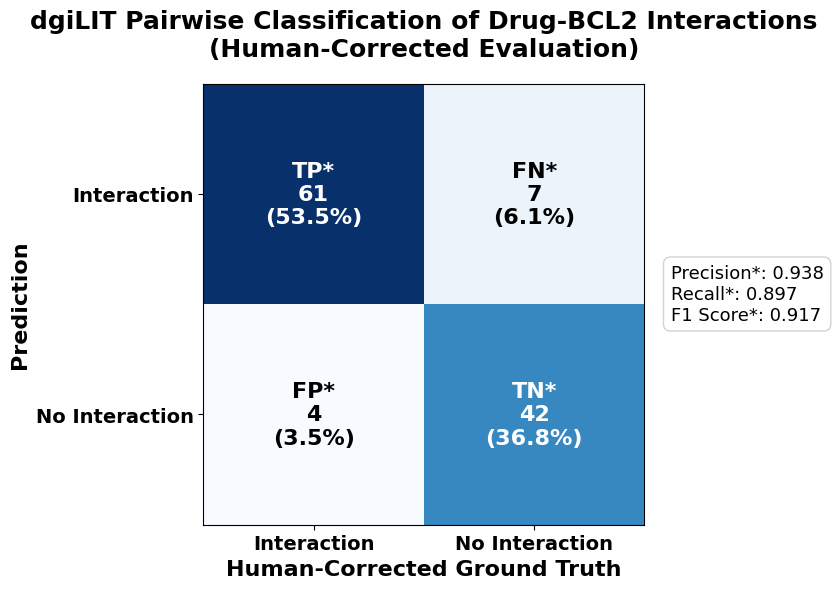

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Human-corrected confusion matrix values
# ------------------------------------------------------------------

tp_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == True)
).sum()

fp_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == True)
).sum()

tn_star = (
    (eval_human["truth_star"] == False)
    & (eval_human["predicted"] == False)
).sum()

fn_star = (
    (eval_human["truth_star"] == True)
    & (eval_human["predicted"] == False)
).sum()

print(
    f"TP*: {tp_star}\n"
    f"FP*: {fp_star}\n"
    f"TN*: {tn_star}\n"
    f"FN*: {fn_star}"
)

cm = np.array([
    [tp_star, fn_star],
    [fp_star, tn_star]
])

total = cm.sum()

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------

precision_star = (
    tp_star / (tp_star + fp_star)
    if (tp_star + fp_star)
    else 0
)

recall_star = (
    tp_star / (tp_star + fn_star)
    if (tp_star + fn_star)
    else 0
)

f1_star = (
    2 * precision_star * recall_star
    / (precision_star + recall_star)
    if (precision_star + recall_star)
    else 0
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Interaction", "No Interaction"],
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Human-Corrected Ground Truth",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Prediction",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "dgiLIT Pairwise Classification of Drug-BCL2 Interactions\n(Human-Corrected Evaluation)",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

# ------------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------------

for i in range(2):
    for j in range(2):

        count = cm[i, j]
        pct = (count / total) * 100

        label = (
            "TP*" if (i == 0 and j == 0)
            else "FN*" if (i == 0 and j == 1)
            else "FP*" if (i == 1 and j == 0)
            else "TN*"
        )

        ax.text(
            j,
            i,
            f"{label}\n{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if count > cm.max() * 0.55 else "black",
        )

# ------------------------------------------------------------------
# Metrics box
# ------------------------------------------------------------------

metrics_text = (
    f"Precision*: {precision_star:.3f}\n"
    f"Recall*: {recall_star:.3f}\n"
    f"F1 Score*: {f1_star:.3f}"
)

plt.figtext(
    0.88,
    0.50,
    metrics_text,
    fontsize=13,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    ),
)

ax.set_aspect("equal")

plt.tight_layout()

# Uncomment to save
# plt.savefig(
#     "bcl2_confusion_matrix_human_corrected.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()